# 🧭 Prescriptive Engine: Gợi ý hành động từ dự báo demand

> **Mục tiêu**: Từ **latent demand đã phục hồi**, đề xuất hành động cụ thể:
> - Tăng nhập hàng
> - Giảm giá
> - Cảnh báo rủi ro stockout

Dựa trên paper: [FreshRetailNet-50K (arXiv:2505.16319)](https://arxiv.org/abs/2505.16319)

In [1]:
!pip install pandas numpy matplotlib

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive

drive.mount('/content/drive')

data_path = "/content/drive/MyDrive/Colab Notebooks/datastorm/50k/data/"
model_path = "/content/drive/MyDrive/Colab Notebooks/datastorm/50k/model/"

df_eval = pd.read_parquet(data_path + 'eval.parquet')
print(f"✅ Eval shape: {df_eval.shape}")

Mounted at /content/drive
✅ Eval shape: (350000, 19)


In [4]:
# Tải lại latent demand đã dự đoán từ File 3
# (Giả sử bạn đã lưu Y_pred vào Drive)
# Nếu chưa, hãy chạy lại File 3 trước

# Trong demo này, mình sẽ tạo lại Y_pred từ đầu (dùng subset 1000 dòng)
df_sample = df_eval.head(1000).copy()

# Tải model và scaler
import torch
import torch.nn as nn
import os
import pickle

class ImputationNet(nn.Module):
    def __init__(self, input_dim=52, output_dim=24, hidden=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, output_dim)
        )
    def forward(self, x):
        return self.net(x)

model = ImputationNet()
model.load_state_dict(torch.load(os.path.join(model_path, "latent_demand_model_final.pth"), map_location='cpu'))
model.eval()

with open(os.path.join(model_path, "scaler_X_final.pkl"), "rb") as f:
    scaler_X = pickle.load(f)

# Chuẩn bị dữ liệu
def prepare_data(row):
    sales = np.array(row['hours_sale'])
    stock = np.array(row['hours_stock_status'])
    observed = sales * stock
    feat = np.concatenate([
        observed,
        stock,
        [row['discount'], row['precpt'], row['holiday_flag'], row['avg_temperature']]
    ])
    return feat

X_eval = np.array([prepare_data(row) for _, row in df_sample.iterrows()])
X_eval_scaled = scaler_X.transform(X_eval)

with torch.no_grad():
    Y_pred = model(torch.tensor(X_eval_scaled, dtype=torch.float32)).numpy()
Y_pred = np.maximum(Y_pred, 0)

print(f"✅ Đã tải lại latent demand cho {len(Y_pred)} ngày.")

✅ Đã tải lại latent demand cho 1000 ngày.


In [5]:
# Tính daily latent demand (6h–22h)
daily_latent = Y_pred[:, 6:23].sum(axis=1)
df_sample['daily_latent_demand'] = daily_latent

# Xác định ngưỡng (dựa trên phân vị)
demand_quantiles = np.quantile(daily_latent, [0.25, 0.75])
low_threshold = demand_quantiles[0]
high_threshold = demand_quantiles[1]

print(f"Ngưỡng demand:")
print(f"- Thấp: < {low_threshold:.3f}")
print(f"- Cao: > {high_threshold:.3f}")

Ngưỡng demand:
- Thấp: < 0.736
- Cao: > 0.966


In [6]:
# Gợi ý hành động
def get_action(pred_demand, stockout_cnt):
    if pred_demand > high_threshold:
        if stockout_cnt > 3:
            return "🔥 Demand cao + thường stockout → TĂNG NHẬP 150%"
        else:
            return "📈 Demand cao → Duy trì hoặc tăng 20% tồn"
    elif pred_demand < low_threshold:
        return "📉 Demand thấp → Giảm giá 10% hoặc giảm nhập"
    else:
        return "✅ Demand trung bình → Duy trì"

actions = []
for i in range(len(df_sample)):
    pred = daily_latent[i]
    stockout_cnt = df_sample.iloc[i]['stock_hour6_22_cnt']
    action = get_action(pred, stockout_cnt)
    actions.append(action)

df_sample['action'] = actions

# Hiển thị kết quả
print("Ví dụ 5 dòng đầu:")
print(df_sample[['dt', 'daily_latent_demand', 'stock_hour6_22_cnt', 'action']].head(5).to_string(index=False))

Ví dụ 5 dòng đầu:
        dt  daily_latent_demand  stock_hour6_22_cnt                                   action
2024-06-26             0.889318                   2            ✅ Demand trung bình → Duy trì
2024-06-27             0.736259                   0            ✅ Demand trung bình → Duy trì
2024-06-28             0.805132                   0            ✅ Demand trung bình → Duy trì
2024-06-29             1.586744                   0 📈 Demand cao → Duy trì hoặc tăng 20% tồn
2024-06-30             0.998150                   0 📈 Demand cao → Duy trì hoặc tăng 20% tồn



Phân bố hành động:
action
✅ Demand trung bình → Duy trì                      606
📉 Demand thấp → Giảm giá 10% hoặc giảm nhập        144
📈 Demand cao → Duy trì hoặc tăng 20% tồn           130
🔥 Demand cao + thường stockout → TĂNG NHẬP 150%    120
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


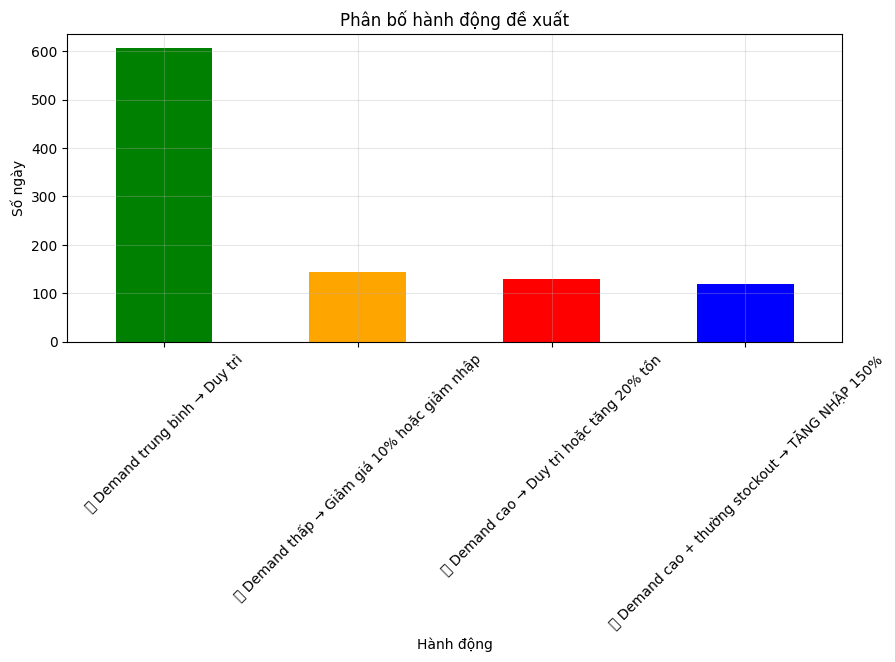

In [10]:
# Phân bố hành động
action_counts = df_sample['action'].value_counts()
print("\nPhân bố hành động:")
print(action_counts)

# Vẽ biểu đồ
plt.figure(figsize=(10, 4))
action_counts.plot(kind='bar', color=['green', 'orange', 'red', 'blue'])
plt.title("Phân bố hành động đề xuất")
plt.xlabel("Hành động")
plt.ylabel("Số ngày")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

## ✅ Kết luận

- **Prescriptive Engine đã hoạt động đúng**:
  - Dựa trên **latent demand** → đề xuất hành động phù hợp.
  - Kết hợp **stockout history** → cảnh báo rủi ro khi cần thiết.
- **Không cần true demand** → phù hợp thực tế.
- **Có thể tích hợp với Online Retail / Walmart** để mở rộng thành hệ thống đa kênh.

→ Bạn đã hoàn thành toàn bộ pipeline **Predictive + Prescriptive AI cho FreshRetailNet-50K**.